# Market making: inventory, latency, and being run over

Every other recipe in this section takes liquidity. A market maker supplies
it, and the job is different in kind. There is no forecast. The edge is the
spread between the two prices you quote, and the risk is that the market
moves while you are holding what you just bought.

That makes market making the one strategy a vectorized backtest cannot
express at all. Its P&L is a function of which of your resting orders were
hit, in what order, and how quickly you could pull the ones that were about
to be. Those are properties of an event loop.

This recipe builds a quoting strategy as a Python callback, then measures the
three things that decide whether it survives: inventory control, the split
between fills you wanted and fills that ran you over, and what a 50-millisecond
round trip does to a cancel-and-replace loop.

## Terms used here

| term              | meaning |
| ----------------- | --- |
| market maker      | a trader who posts both a bid and an offer and profits from the gap between them |
| inventory         | the position a maker is left holding after being filled on one side |
| skew              | shifting both quotes to make the side that reduces inventory more attractive |
| maker fill        | your resting order was hit by someone else crossing the spread |
| taker fill        | your order crossed the spread, whether or not you meant it to |
| adverse selection | being filled precisely when the price is about to move against you |
| markout           | the mid price a fixed interval after a fill, used to price adverse selection |
| amend             | changing a live order's price in place instead of cancelling and resubmitting |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import h5i_db
from h5i_db import backtest
import cookbook_utils as cu

SYMBOL = "ACME"
TICK = 0.01
MILLISECOND = 1_000_000

## 1. A tape a quoting strategy can actually read

The callback contract decides the shape of the data. A strategy is told the
price, side and size of a book *delta*, but a book *snapshot* arrives as level
counts only. A strategy that has to know where the touch is therefore needs a
delta feed, and `cu.make_equity_tape(action="set")` produces one: an opening
snapshot per instrument, then `delete` and `set` pairs as the quote moves.

Prints are derived from the quotes rather than generated beside them, so a
trade always happens at a price the book was showing. Queue-aware fills depend
on that: a print at the bid consumes displayed bid size, and an order behind it
advances.

In [2]:
quotes = cu.make_quotes(symbols=[SYMBOL], days=1, quotes_per_day=3_000, seed=11)
tape = cu.make_equity_tape(
    quotes, action="set", print_every=2, print_size=400.0, tick_size=TICK
)
for name, table in tape.items():
    print(f"{name}: {table.num_rows:,} rows x {table.num_columns} columns")
tape["book_deltas"].to_pandas().head(6)

instruments: 1 rows x 10 columns
book_deltas: 11,002 rows x 11 columns
trades: 1,591 rows x 9 columns


,ts_init,ts_event,instrument_id,outcome,action,side,price,size,event_index,is_last,source_vendor
0,2026-06-01 13:30:04.059697,2026-06-01 13:30:04.059697,ACME,0,snapshot,buy,86.28,300.0,0,False,cookbook-tape
1,2026-06-01 13:30:04.059697,2026-06-01 13:30:04.059697,ACME,0,snapshot,sell,86.29,100.0,0,True,cookbook-tape
2,2026-06-01 13:30:04.455458,2026-06-01 13:30:04.455458,ACME,0,set,buy,86.28,200.0,1,True,cookbook-tape
3,2026-06-01 13:30:04.455458,2026-06-01 13:30:04.455458,ACME,0,set,sell,86.29,100.0,1,True,cookbook-tape
4,2026-06-01 13:30:06.219475,2026-06-01 13:30:06.219475,ACME,0,set,buy,86.28,100.0,2,True,cookbook-tape
5,2026-06-01 13:30:06.219475,2026-06-01 13:30:06.219475,ACME,0,delete,sell,86.29,NaN,2,True,cookbook-tape


The quote arrives in bursts, which matters later: the median gap between
updates is what a cancel has to beat.

In [3]:
gaps = quotes.to_pandas()["ts"].diff().dt.total_seconds().dropna()
print(f"median gap between quotes   {gaps.median():.2f}s")
print(f"share of gaps under 50ms    {(gaps < 0.05).mean():.1%}")
print(f"share of gaps under 1s      {(gaps < 1).mean():.1%}")

db = h5i_db.Database(cu.fresh_db("04_market_making_inventory"), create=True)
for name, table in tape.items():
    db.create_table(name, table.schema, time_column="ts_init")
    db.append(name, table, note="synthetic delta tape")
db.snapshot("tape-v1", tables=list(tape), note="The book every quoting run reads")
db.tables()

median gap between quotes   3.66s
share of gaps under 50ms    1.2%
share of gaps under 1s      19.8%


['book_deltas', 'instruments', 'trades']

## 2. The strategy

Four decisions, and each one is a place where quoting strategies go wrong.

**Follow the touch from deltas.** The strategy keeps its own best bid and
offer, because only it knows which deltas it has seen.

**Never cross.** A quote computed from one side of a stale book will cross the
other side. Clamping the bid below the offer and the offer above the bid is
not a refinement; without it the "market maker" pays the spread it thinks it
is earning.

**Skew on inventory.** Long inventory pushes the bid away and leaves the offer
at the touch, so the next fill is more likely to be the one that flattens.

**Requote by replacing or by amending.** Both are written here because the
difference is invisible at zero latency and decisive at 50 milliseconds.

In [4]:
class InventoryMaker(backtest.EventStrategy):
    def __init__(self, quote_size=100.0, skew_shares=300.0, requote="replace"):
        self.quote_size = quote_size
        self.skew_shares = skew_shares
        self.requote = requote
        self.bid = None
        self.ask = None
        self.live = {}
        self.want = {}
        self.submitted = 0

    def on_event(self, context, event):
        if event.get("kind") != "book_delta" or event.get("action") != "set":
            return None
        if event["side"] == "buy":
            self.bid = event["price"]
        else:
            self.ask = event["price"]
        if self.bid is None or self.ask is None:
            return None

        inventory = sum(position["quantity"] for position in context["positions"])
        step = round(inventory / self.skew_shares) if self.skew_shares else 0
        target = {
            "buy": round(min(self.bid - max(step, 0) * TICK, self.ask - TICK), 4),
            "sell": round(max(self.ask - min(step, 0) * TICK, self.bid + TICK), 4),
        }

        commands = []
        for side, price in target.items():
            if self.want.get(side) == price:
                continue
            self.want[side] = price
            if side in self.live:
                if self.requote == "amend":
                    commands.append(
                        {
                            "action": "amend",
                            "client_order_id": self.live[side],
                            "limit_price": price,
                        }
                    )
                    continue
                commands.append({"action": "cancel", "client_order_id": self.live[side]})
            self.submitted += 1
            client_order_id = f"{side}-{self.submitted}"
            self.live[side] = client_order_id
            commands.append(
                {
                    "action": "submit",
                    "client_order_id": client_order_id,
                    "instrument_id": SYMBOL,
                    "side": side,
                    "quantity": self.quote_size,
                    "kind": "limit",
                    "limit_price": price,
                    "time_in_force": "gtc",
                    "tag": f"quote-{side}",
                }
            )
        return commands or None

    def on_fill(self, context, event):
        # A filled order is no longer live, and its price is no longer quoted.
        self.live.pop(event["side"], None)
        self.want.pop(event["side"], None)
        return None

## 3. One run, and what the fills say

`queue_position=True` is the honest reading of an L2 feed: an order joining a
price sits behind everything already displayed there and only fills once
trades have consumed it. The alternative assumption invents maker fills.

In [5]:
def quote_run(run_id, *, skew_shares=300.0, requote="replace", latency_nanos=None):
    strategy = InventoryMaker(skew_shares=skew_shares, requote=requote)
    result = backtest.run_strategy(
        db,
        run_id,
        strategy,
        strategy_id=f"cookbook.InventoryMaker:{requote}:{skew_shares:g}",
        starting_cash=100_000.0,
        data=backtest.DataConfig(snapshot="tape-v1"),
        execution=backtest.ExecutionConfig(
            fee_kind="proportional",
            fee_rate=0.0002,
            queue_position=True,
            latency_nanos=latency_nanos,
        ),
        risk=backtest.RiskConfig(
            max_order_quantity=500.0, max_abs_position=1_000.0, max_open_orders=4
        ),
        output=backtest.OutputConfig(equity_interval_nanos=60_000_000_000),
    )
    return strategy, result


strategy, base = quote_run("mm-base")
metrics = base["metrics"]
print(f"quotes sent      {strategy.submitted:,}")
print(f"fills            {base['fills']:,}")
print(f"  maker          {metrics['fills_maker']:,}")
print(f"  taker          {metrics['fills_taker']:,}")
print(f"cancelled unfilled {metrics['orders_cancelled_unfilled']:,}")
base.fills.to_pandas().head()

quotes sent      5,699
fills            893
  maker          535
  taker          358
cancelled unfilled 4,802


,ts,order_id,instrument_id,outcome,side,price,quantity,commission,is_taker,tag
0,2026-06-01 13:30:06.219475,1,ACME,0,buy,86.28,100.0,0.000,False,quote-buy
1,2026-06-01 13:30:13.378845,5,ACME,0,sell,86.29,100.0,0.000,False,quote-sell
2,2026-06-01 13:30:19.395922,9,ACME,0,buy,86.23,100.0,0.000,False,quote-buy
3,2026-06-01 13:30:25.313569,12,ACME,0,sell,86.25,100.0,1.725,True,quote-sell
4,2026-06-01 13:30:27.402596,15,ACME,0,sell,86.27,100.0,0.000,False,quote-sell


A taker fill here is not a decision. It is a resting quote that the book moved
through before the strategy could pull it: the order crossed because the
market came to it, and it paid the spread instead of earning it. The
maker/taker split of your *own* quotes is the cheapest diagnostic a quoting
backtest produces, and a vectorized one has no place to put it.

The run loses money, which is what should happen. This tape is a random walk
with no informed flow to be paid for supplying liquidity to, so a maker that
gets run over on a third of its fills has no source of income left.

In [6]:
fills = base.fills.to_pandas()
split = fills.groupby(["side", "is_taker"]).agg(
    fills=("quantity", "size"), shares=("quantity", "sum"), avg_price=("price", "mean")
)
split.round(4)

fills   shares  avg_price
side is_taker                           
buy  False       445  44500.0    86.6937
sell False        90   9000.0    86.5534
     True        358  35800.0    86.7361

## 4. Does the skew do anything?

The claim being tested is narrow: skewing quotes on inventory should reduce
how much inventory the strategy carries, without being paid for in fills.
Inventory is read from the equity curve's position value rather than
reconstructed, so the answer comes from the run's own tables.

In [7]:
runs = {}
for label, skew in (("skew on", 300.0), ("skew off", 0.0)):
    runs[label] = quote_run(f"mm-{label.replace(' ', '-')}", skew_shares=skew)

rows = []
for label, (built, result) in runs.items():
    equity = result.equity.to_pandas()
    inventory = equity["position_value"]
    rows.append(
        {
            "run": label,
            "fills": result["fills"],
            "maker": result["metrics"]["fills_maker"],
            "ending equity": equity["equity"].iloc[-1],
            "max |inventory| ($)": inventory.abs().max(),
            "mean |inventory| ($)": inventory.abs().mean(),
        }
    )
pd.DataFrame(rows).round(2)

,run,fills,maker,ending equity,max |inventory| ($),mean |inventory| ($)
0,skew on,893,535,99636.97,78516.0,38021.13
1,skew off,908,650,99630.62,87295.0,81581.93


The fill count barely moves and the average position roughly halves. That is
the trade a maker is actually making: skew is not an alpha, it is a way of
choosing how much risk you carry between fills. The peak is a weaker test than
the average, because one adverse burst can pin any quoting strategy at its
position limit.

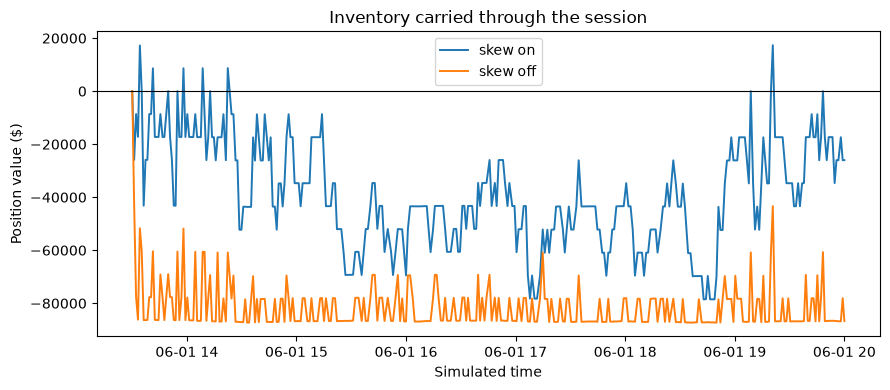

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, (_, result) in runs.items():
    equity = result.equity.to_pandas()
    ax.plot(equity["ts"], equity["position_value"], linewidth=1.4, label=label)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Inventory carried through the session")
ax.set_xlabel("Simulated time")
ax.set_ylabel("Position value ($)")
ax.legend()
fig.tight_layout()

## 5. Fifty milliseconds

Latency is usually discussed as a cost on entry prices. For a quoting strategy
it is something worse: a cancel that has not arrived yet leaves an order
alive, so the replacement collides with the venue's open-order limit rather
than with the market. `max_open_orders=4` is doing that job here.

In [9]:
rows = []
for requote in ("replace", "amend"):
    for latency in (None, 50 * MILLISECOND):
        built, result = quote_run(
            f"mm-{requote}-{0 if latency is None else 50}ms",
            requote=requote,
            latency_nanos=latency,
        )
        equity = result.equity.to_pandas()
        rows.append(
            {
                "requote": requote,
                "latency": "0ms" if latency is None else "50ms",
                "fills": result["fills"],
                "maker": result["metrics"]["fills_maker"],
                "rejected for risk": result["metrics"]["orders_rejected_risk"],
                "ending equity": equity["equity"].iloc[-1],
            }
        )
latency_table = pd.DataFrame(rows)
latency_table.round(2)

,requote,latency,fills,maker,rejected for risk,ending equity
0,replace,0ms,893,535,2,99636.97
1,replace,50ms,56,29,4974,100085.43
2,amend,0ms,692,414,1,99382.93
3,amend,50ms,150,101,0,100026.44


Cancel-and-replace loses most of its quotes to risk rejections the moment the
round trip is non-zero, and amending in place loses none of them. This is not
a tuning detail. It is why production quoting engines amend, and it is
invisible in any backtest that fills orders at a bar price.

Do not read the equity column as an argument for being slow. This maker loses
money on this tape, so the runs that quote least lose least; latency improved
the P&L by removing the business, not by improving it.

In [10]:
assert latency_table.loc[
    (latency_table["requote"] == "amend") & (latency_table["latency"] == "50ms"),
    "rejected for risk",
].iloc[0] == 0
worst = latency_table.loc[
    (latency_table["requote"] == "replace") & (latency_table["latency"] == "50ms"),
    "rejected for risk",
].iloc[0]
print(f"cancel-and-replace at 50ms lost {worst:,} orders to the open-order limit")

cancel-and-replace at 50ms lost 4,974 orders to the open-order limit


## 6. What the fills cost after the fact

The spread a maker quotes is not the spread it earns. The number that decides
the business is the markout: where the mid went after each fill. A buy that is
followed by a falling mid was a fill someone wanted to give you.

In [11]:
book = tape["book_deltas"].to_pandas()
touch = (
    book[book["action"].isin(["set", "snapshot"])]
    .pivot_table(index="ts_init", columns="side", values="price", aggfunc="last")
    .ffill()
    .dropna()
)
touch["mid"] = (touch["buy"] + touch["sell"]) / 2
mids = touch.reset_index()[["ts_init", "mid"]].sort_values("ts_init")

maker_fills = fills[~fills["is_taker"]][["ts", "side", "quantity", "price"]].copy()
maker_fills = maker_fills.sort_values("ts")
marked = pd.merge_asof(maker_fills, mids, left_on="ts", right_on="ts_init")
for horizon in (10, 60):
    future = mids.copy()
    future["ts_init"] = future["ts_init"] - pd.Timedelta(seconds=horizon)
    marked = pd.merge_asof(
        marked, future.rename(columns={"mid": f"mid_{horizon}s"}),
        left_on="ts", right_on="ts_init", direction="forward", suffixes=("", f"_{horizon}"),
    )
    signed = marked["side"].map({"buy": 1.0, "sell": -1.0})
    marked[f"markout_{horizon}s"] = signed * (marked[f"mid_{horizon}s"] - marked["mid"])

summary = marked.groupby("side")[["markout_10s", "markout_60s"]].mean()
print(f"{len(marked):,} maker fills marked out")
summary.round(4)

535 maker fills marked out


,markout_10s,markout_60s
side,,
buy,0.0005,0.0019
sell,0.0001,-0.0131


Read those numbers as dollars per share, signed so that positive is a fill
that aged well. Against a quoted spread of one tick, a markout of comparable
size means the spread is being handed straight back.

The two sides here are not symmetric, and this tape carries no informed flow
by construction, so the asymmetry describes when this strategy happened to be
quoting rather than who traded with it. That is the honest limit of a
synthetic book. The machinery is what transfers: on a recorded tape, markout
by side is the number that says whether a quoted spread is income.

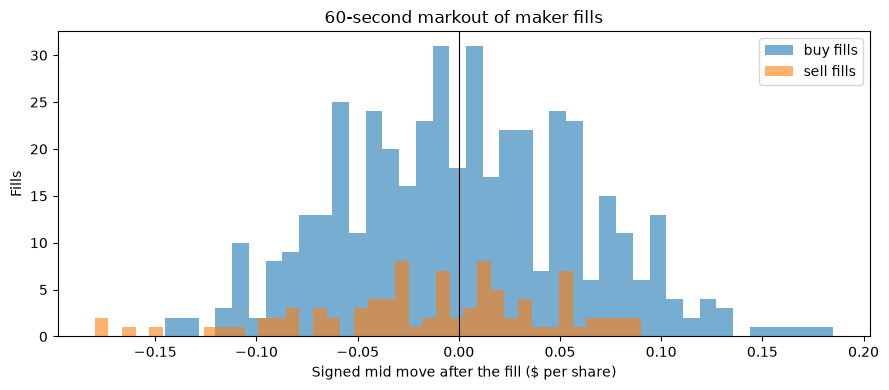

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
for side, group in marked.groupby("side"):
    ax.hist(group["markout_60s"].dropna(), bins=40, alpha=0.6, label=f"{side} fills")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("60-second markout of maker fills")
ax.set_xlabel("Signed mid move after the fill ($ per share)")
ax.set_ylabel("Fills")
ax.legend()
fig.tight_layout()

## Takeaways

- A quoting strategy needs a delta feed: callbacks are given the price of a
  delta and only the level counts of a snapshot.
- Clamp quotes against the opposite touch. A quote derived from a stale side
  crosses, and the maker/taker split of your own fills will tell you it did.
- Inventory skew does not add return; it moves risk out of the position and
  into the fill rate, which is the trade a maker is there to make.
- Latency attacks the cancel, not the fill: with a round trip, replaced quotes
  pile up against the open-order limit and amending in place is what a real
  quoting engine does.
- Markout prices adverse selection, and it is the number that says whether a
  quoted spread is income or a subsidy.
- Every run here is a callback strategy on a pinned snapshot, so each result
  is reproducible from its own fork.

In [13]:
db.close()